<a href="https://colab.research.google.com/github/akinola1718/myscrapers-beg24003-root/blob/main/Model%20Trending%20Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Clone repo
!git clone https://github.com/akinola1718/myscrapers-beg24003-root.git myrepo

Cloning into 'myrepo'...
remote: Enumerating objects: 907, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 907 (delta 62), reused 11 (delta 4), pack-reused 819 (from 1)
Receiving objects: 100% (907/907), 276.84 KiB | 2.37 MiB/s, done.
Resolving deltas: 100% (455/455), done.


In [8]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
import os

os.makedirs("figs", exist_ok=True)

In [10]:
# Read all synced preds files
files = sorted(glob.glob("myrepo/results/*-preds_llm.csv"))
print(files)

['myrepo/results/2026040503-preds_llm.csv', 'myrepo/results/2026040505-preds_llm.csv', 'myrepo/results/2026040507-preds_llm.csv', 'myrepo/results/2026040508-preds_llm.csv', 'myrepo/results/2026040509-preds_llm.csv', 'myrepo/results/2026040510-preds_llm.csv', 'myrepo/results/2026040511-preds_llm.csv', 'myrepo/results/2026040513-preds_llm.csv', 'myrepo/results/2026040514-preds_llm.csv', 'myrepo/results/2026040515-preds_llm.csv', 'myrepo/results/2026040516-preds_llm.csv', 'myrepo/results/2026040517-preds_llm.csv', 'myrepo/results/2026040519-preds_llm.csv', 'myrepo/results/2026040520-preds_llm.csv', 'myrepo/results/2026040521-preds_llm.csv', 'myrepo/results/2026040522-preds_llm.csv', 'myrepo/results/2026040523-preds_llm.csv', 'myrepo/results/2026040603-preds_llm.csv', 'myrepo/results/2026040606-preds_llm.csv', 'myrepo/results/2026040607-preds_llm.csv', 'myrepo/results/2026040609-preds_llm.csv', 'myrepo/results/2026040611-preds_llm.csv', 'myrepo/results/2026040612-preds_llm.csv', 'myrepo/re

In [11]:
# 4) Build trending table
rows = []

for f in files:
    name = os.path.basename(f)
    run_id = name.replace("-preds_llm.csv", "")   # e.g. 2026040508
    timestamp = pd.to_datetime(run_id, format="%Y%m%d%H", errors="coerce")

    df = pd.read_csv(f)

    if "actual_price" not in df.columns or "pred_price" not in df.columns:
        continue

    y_true = pd.to_numeric(df["actual_price"], errors="coerce")
    y_pred = pd.to_numeric(df["pred_price"], errors="coerce")
    mask = y_true.notna() & y_pred.notna() & (y_true != 0)

    if mask.sum() == 0:
        continue

    rows.append({
        "run_id": run_id,
        "timestamp": timestamp,
        "holdout_rows": int(mask.sum()),
        "mae": mean_absolute_error(y_true[mask], y_pred[mask]),
        "rmse": np.sqrt(mean_squared_error(y_true[mask], y_pred[mask])),
        "mape": np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])),
        "bias": float((y_pred[mask] - y_true[mask]).mean()),
        "r2": r2_score(y_true[mask], y_pred[mask]) if mask.sum() >= 2 else np.nan
    })

trend_df = pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)
trend_df

,run_id,timestamp,holdout_rows,mae,rmse,mape,bias,r2
0,2026040503,2026-04-05 03:00:00,113,5941.083982,12760.751017,0.642063,-456.240973,0.671319
1,2026040505,2026-04-05 05:00:00,19,12953.145263,23120.881161,0.777687,386.408421,0.677827
2,2026040507,2026-04-05 07:00:00,30,9491.733667,18688.313248,0.593487,-566.082333,0.687998
3,2026040508,2026-04-05 08:00:00,40,8607.148750,16811.894680,0.540315,-1173.467250,0.693877
4,2026040509,2026-04-05 09:00:00,47,8424.923830,16612.985583,0.671663,-579.338723,0.655948
5,2026040510,2026-04-05 10:00:00,52,8028.981731,15960.957665,0.624678,-919.487500,0.655577
6,2026040511,2026-04-05 11:00:00,58,7753.169655,15316.741975,0.662574,-100.520345,0.652288
7,2026040513,2026-04-05 13:00:00,64,7281.722031,14605.990832,0.629163,-81.918281,0.653928
8,2026040514,2026-04-05 14:00:00,67,7061.477015,14275.463812,0.626672,-91.419104,0.655980
9,2026040515,2026-04-05 15:00:00,71,6901.800423,13931.270830,0.611657,-318.301831,0.655575


In [12]:
# 5) Save summary
trend_df.to_csv("myrepo/results/model_trending_summary.csv", index=False)
trend_df

,run_id,timestamp,holdout_rows,mae,rmse,mape,bias,r2
0,2026040503,2026-04-05 03:00:00,113,5941.083982,12760.751017,0.642063,-456.240973,0.671319
1,2026040505,2026-04-05 05:00:00,19,12953.145263,23120.881161,0.777687,386.408421,0.677827
2,2026040507,2026-04-05 07:00:00,30,9491.733667,18688.313248,0.593487,-566.082333,0.687998
3,2026040508,2026-04-05 08:00:00,40,8607.148750,16811.894680,0.540315,-1173.467250,0.693877
4,2026040509,2026-04-05 09:00:00,47,8424.923830,16612.985583,0.671663,-579.338723,0.655948
5,2026040510,2026-04-05 10:00:00,52,8028.981731,15960.957665,0.624678,-919.487500,0.655577
6,2026040511,2026-04-05 11:00:00,58,7753.169655,15316.741975,0.662574,-100.520345,0.652288
7,2026040513,2026-04-05 13:00:00,64,7281.722031,14605.990832,0.629163,-81.918281,0.653928
8,2026040514,2026-04-05 14:00:00,67,7061.477015,14275.463812,0.626672,-91.419104,0.655980
9,2026040515,2026-04-05 15:00:00,71,6901.800423,13931.270830,0.611657,-318.301831,0.655575


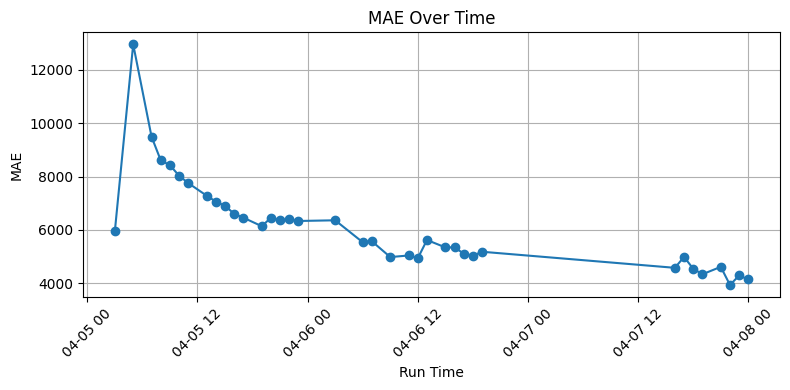

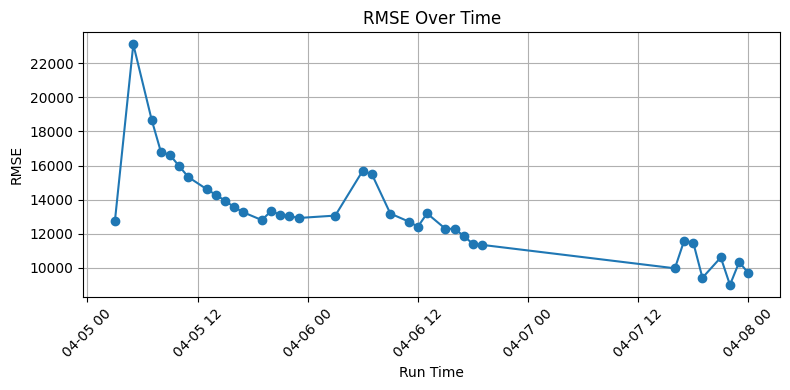

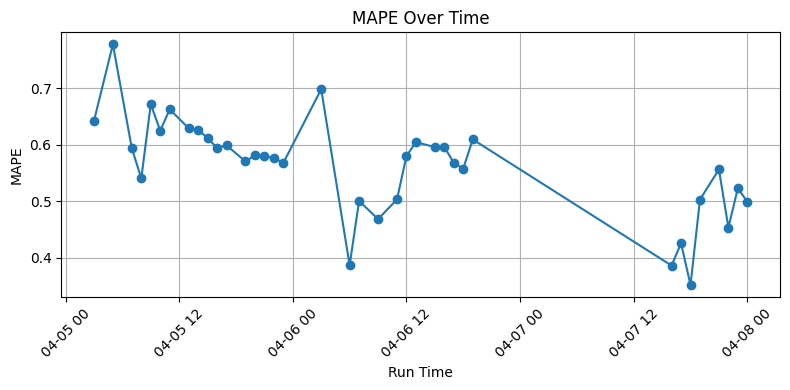

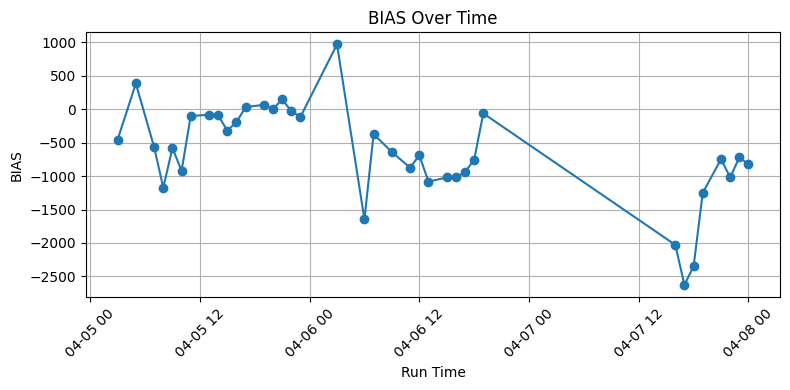

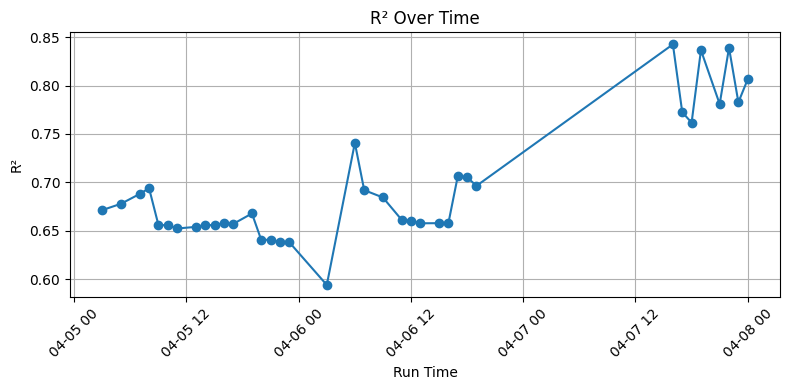

In [13]:
metrics = ["mae", "rmse", "mape", "bias", "r2"]

for metric in metrics:
    plt.figure(figsize=(8,4))
    plt.plot(trend_df["timestamp"], trend_df[metric], marker="o")
    plt.xlabel("Run Time")
    plt.ylabel(metric.upper() if metric != "r2" else "R²")
    plt.title(f"{metric.upper() if metric != 'r2' else 'R²'} Over Time")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()

    # ✅ SAVE FIGURE
    filename = f"figs/{metric}_trend.png"
    plt.savefig(filename, dpi=150)

    plt.show()